# XSIGHT Chest X-Ray Classifier — Colab Training Notebook

Trains an EfficientNet-B0 to predict one of 8 labels:
`normal | pneumonia | covid | tuberculosis | effusion | cardiomegaly | mass | other`.

Outputs:
- `xray.pt`  — PyTorch state_dict
- `xray.onnx` — ONNX export
- `labels.json` — label list (index → string)
- `metrics.json` — per-class precision/recall/AUROC, confusion matrix, and a
  fitted `temperature` value used for softmax calibration at inference time
- `confusion.png` — confusion matrix heatmap

Drop these into `server/ml/xray/` on the XSIGHT backend and restart `python main.py`.

**Dataset sources added:** RSNA Pneumonia, COVID-19 Radiography Database,
NIH ChestX-ray14, and TB datasets. Verify each dataset's license/terms before use.
COVID X-rays overlap visually with pneumonia; this is a screening classifier,
not a diagnostic test.

## 1. Setup

In [1]:
!pip install  timm torchmetrics scikit-learn pandas pillow matplotlib pydicom kaggle kagglehub
import torch, json, os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device =', DEVICE, '| torch =', torch.__version__)

try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive', force_remount=True)
    DRIVE_ROOT = Path('/content/drive/MyDrive/xsight_ai')
    OUT = DRIVE_ROOT / 'xray_output'
    DATA_ROOT = DRIVE_ROOT / 'datasets'
else:
    DRIVE_ROOT = Path('./xsight_ai').resolve()
    OUT = DRIVE_ROOT / 'xray_output'
    DATA_ROOT = DRIVE_ROOT / 'datasets'

OUT.mkdir(parents=True, exist_ok=True)
DATA_ROOT.mkdir(parents=True, exist_ok=True)
print(f'Running in Colab: {IN_COLAB}')
print(f'Google Drive project: {DRIVE_ROOT}')
print(f'Output dir: {OUT}')
print(f'Data dir: {DATA_ROOT}')

Mounted at /content/drive
Running in Colab: True
Google Drive project: /content/drive/MyDrive/xsight_ai
Output dir: /content/drive/MyDrive/xsight_ai/xray_output
Data dir: /content/drive/MyDrive/xsight_ai/datasets


## 2. Download RSNA Pneumonia Detection (Kaggle)

Requires a Kaggle account and competition rule acceptance.
1. Go to https://www.kaggle.com/settings → API → Create New Token → download `kaggle.json`
2. Accept rules at https://www.kaggle.com/c/rsna-pneumonia-detection-challenge/rules
3. Run this cell and upload your `kaggle.json` when prompted. The same credentials
   are reused by the Kaggle TB downloads in section 4.

In [ ]:
# Kaggle auth is configured in the next cell.
# Preferred: store kaggle.json at MyDrive/xsight_ai/kaggle.json.
# Never paste tokens into this notebook; rotate any token previously exposed.

In [5]:
import os, zipfile, shutil, json
from pathlib import Path
from tqdm.auto import tqdm

# --- 1. Kaggle credentials ---
KAGGLE_DIR = Path.home() / '.kaggle'
KAGGLE_DIR.mkdir(parents=True, exist_ok=True)
KAGGLE_JSON_DEST = KAGGLE_DIR / 'kaggle.json'

drive_src = DRIVE_ROOT / 'kaggle.json'
local_src = Path('/home/jay/Documents/project/tupi/xsight/kaggle.json')

if drive_src.exists():
    shutil.copy2(drive_src, KAGGLE_JSON_DEST)
elif local_src.exists() and not IN_COLAB:
    shutil.copy2(local_src, KAGGLE_JSON_DEST)
else:
    raise FileNotFoundError(f'Place kaggle.json at {drive_src}')

KAGGLE_JSON_DEST.chmod(0o600)
print(f'Kaggle credentials configured from {drive_src if drive_src.exists() else local_src}')

# --- 2. Download + extract RSNA ---
RSNA_DIR = DATA_ROOT / 'rsna'
RSNA_DIR.mkdir(parents=True, exist_ok=True)

if not (RSNA_DIR / 'stage_2_train_labels.csv').exists():
    import kaggle
    print('Downloading RSNA Pneumonia Detection (~1.2 GB)...')
    kaggle.api.competition_download_files(
        'rsna-pneumonia-detection-challenge',
        path=str(RSNA_DIR),
        quiet=False,
    )
    for z in RSNA_DIR.glob('*.zip'):
        print(f'Extracting: {z.name} ({z.stat().st_size / 1e9:.2f} GB)')
        with zipfile.ZipFile(z) as zf:
            for info in tqdm(zf.infolist(), desc='Extracting', unit='file'):
                zf.extract(info, RSNA_DIR)
        z.unlink()
    print('Extraction complete.')
else:
    print('RSNA already cached.')

print('RSNA ready:', RSNA_DIR)

Kaggle credentials configured from /content/drive/MyDrive/xsight_ai/kaggle.json
rsna-pneumonia-detection-challenge.zip: Skipping, found more recently modified local copy (use --force to force download)
Extracting: rsna-pneumonia-detection-challenge.zip (3.93 GB)


Extracting:   0%|          | 0/29688 [00:00<?, ?file/s]

Extraction complete.
RSNA ready: /content/drive/MyDrive/xsight_ai/datasets/rsna


## 2b. Download COVID-19 Radiography Database (Kaggle)

Uses `tawsifurrahman/covid19-radiography-database`: COVID, Viral Pneumonia,
Normal, and Lung_Opacity images. COVID maps to `covid`, Viral Pneumonia to
`pneumonia`, Lung_Opacity to `other`. Check dataset terms/citation before use.

Recommended additional datasets (check access/license):
- `piyushagni5/covid19-radiography-database` — smaller duplicate/mirror.
- `prashant268/covid19-cxr-image-dataset` — smaller COVID CXR collection.
- COVIDx — larger benchmark; use official metadata/splits, not filename inference.

In [7]:
import zipfile
from tqdm.auto import tqdm

COVID_DIR = DATA_ROOT / 'covid'
COVID_DIR.mkdir(parents=True, exist_ok=True)
if not any(COVID_DIR.rglob('*.png')):
    import kaggle
    print('Downloading COVID-19 Radiography Database...')
    kaggle.api.dataset_download_files(
        'tawsifurrahman/covid19-radiography-database',
        path=str(COVID_DIR),
        quiet=False,
    )
    for z in COVID_DIR.glob('*.zip'):
        print(f'Extracting: {z.name} ({z.stat().st_size / 1e6:.1f} MB)')
        with zipfile.ZipFile(z) as zf:
            for info in tqdm(zf.infolist(), desc='Extracting', unit='file'):
                zf.extract(info, COVID_DIR)
        z.unlink()
    print('Extraction complete.')
else:
    print('COVID already cached.')

print('COVID PNG files:', len(list(COVID_DIR.rglob('*.png'))))

COVID already cached.
COVID PNG files: 2324


## 3. Download NIH ChestX-ray14 (HuggingFace)

No authentication needed. `NIH_LIMIT = None` downloads the full ~112k set
(several GB, slower). Set it to e.g. `5000` for a quick prototyping run —
but note the full set gives the `other`/`effusion`/`cardiomegaly`/`mass`
classes far more examples, which matters as much as the TB fix below since
those classes were also thin under the old 5000-image cap.

In [8]:
import zipfile
from tqdm.auto import tqdm

NIH_LIMIT = None
NIH_DIR = DATA_ROOT / 'nih'

# If the directory exists but is empty, remove it to trigger a fresh download
if NIH_DIR.exists() and not any(NIH_DIR.iterdir()):
    print('Removing empty cache directory...')
    import shutil
    shutil.rmtree(NIH_DIR)

if not NIH_DIR.exists():
    print('Downloading NIH ChestX-ray14 from Kaggle...')
    import kaggle
    import sys

    # Use the verified ID from the search results
    kaggle_dataset_id = 'khanfashee/nih-chest-x-ray-14-224x224-resized'
    NIH_DIR.mkdir(parents=True, exist_ok=True)

    try:
        kaggle.api.dataset_download_files(
            kaggle_dataset_id,
            path=str(NIH_DIR),
            quiet=False,
        )
        for z in NIH_DIR.glob('*.zip'):
            print(f'Extracting: {z.name} ({z.stat().st_size / 1e9:.2f} GB)')
            with zipfile.ZipFile(z) as zf:
                for info in tqdm(zf.infolist(), desc='Extracting', unit='file'):
                    zf.extract(info, NIH_DIR)
            z.unlink()
        print('Done downloading and unzipping.')
    except Exception as e:
        if '403' in str(e):
            print(f'\n[!] ACCESS DENIED (403): You must accept terms at: https://www.kaggle.com/datasets/{kaggle_dataset_id}')
        else:
            print(f'Download failed: {e}')
else:
    print('NIH already cached with files.')

img_check = list(NIH_DIR.rglob('*.png'))[:5]
print('Files found:', [f.name for f in img_check])

Dataset URL: https://www.kaggle.com/datasets/khanfashee/nih-chest-x-ray-14-224x224-resized


100%|██████████| 2.30G/2.30G [00:26<00:00, 93.4MB/s]



Extracting: nih-chest-x-ray-14-224x224-resized.zip (2.47 GB)


Extracting:   0%|          | 0/112125 [00:00<?, ?file/s]

Done downloading and unzipping.
Files found: ['00000001_000.png', '00000001_001.png', '00000001_002.png', '00000002_000.png', '00000003_000.png']


In [12]:
import kaggle
# Search for active NIH Chest X-ray datasets
!kaggle datasets list -s "NIH Chest X-ray"

ref                                                           title                                                      size  lastUpdated                 downloadCount  voteCount  usabilityRating  
------------------------------------------------------------  --------------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
nih-chest-xrays/sample                                        Random Sample of NIH Chest X-ray Dataset             4506359620  2017-11-23 02:58:24.087000          30522        302  0.7647059        
nih-chest-xrays/data                                          NIH Chest X-rays                                    45096150231  2018-02-21 20:52:23.880000         253431       1629  0.7352941        
khanfashee/nih-chest-x-ray-14-224x224-resized                 NIH Chest X ray 14 (224x224 resized)                 2468882507  2020-07-08 09:36:37.193000           8639         31  0.64705884       
hutha

If the original dataset is truly gone, we can try using `kagglehub` for a different version, which often handles the download more robustly in Colab:

In [13]:
import kagglehub
# Try downloading a widely used alternative NIH dataset version
try:
    path = kagglehub.dataset_download("nih-dataset/nih-chest-xrays")
    print("Dataset path:", path)
except Exception as e:
    print(f"Download failed: {e}")

Download failed: 403 Client Error.

You don't have permission to access resource at URL: https://api.kaggle.com/v1/datasets.DatasetApiService/GetDataset. Please make sure you are authenticated if you are trying to access a private resource or a resource requiring consent.


## 4. Download TB datasets (Shenzhen + Montgomery + Kaggle TB + TBX11K)

The original recipe only used Shenzhen (~662 TB) + Montgomery (~58 TB) —
under 720 TB images total, which is why the shipped model was confidently
wrong on real TB films (too few, too homogeneous positive examples for the
minority class). This adds two more public sources:

- **Shenzhen Hospital** (HuggingFace) — ~662 TB + ~326 normal
- **Montgomery County** (HuggingFace) — 58 TB + 80 normal
- **Kaggle TB Chest X-ray Database** (`tawsifurrahman/tuberculosis-tb-chest-xray-dataset`)
  — ~700 TB + ~3,500 normal. Requires the Kaggle credentials from section 2.
- **TBX11K Simplified** (`vbookshelf/tbx11k-simplified`) — ~800 labeled TB
  images plus thousands of `sick_but_non_tb` images we map to `other`,
  which gives the model real negative examples that look diseased but
  aren't TB — important for reducing TB false positives too.

Combined this brings TB coverage from ~720 to roughly 2,000+ images —
still the minority class, which is why section 10 also adds
**oversampling** (not just loss weighting) for the train split.

Folder layouts for the two new Kaggle sources aren't perfectly documented,
so the loader below walks the downloaded tree and infers labels from
path component keywords (`tuberculosis`/`tb` vs `normal`/`health` vs
`sick`/`non_tb`). It prints per-source counts — **check these against the
dataset page before trusting a full training run**, and treat a source as
misconfigured if a class comes back near-zero when it shouldn't.

In [9]:
!pip install  datasets

import kagglehub
import shutil
import re
from pathlib import Path

TB_DIR = DATA_ROOT / 'tb'
TB_DIR.mkdir(parents=True, exist_ok=True)
re_tb = re.compile(r'(?<![a-z])tb(?![a-z])')

def _infer_label(path_str: str) -> str | None:
    p = path_str.lower()
    if 'mask' in p: return None
    if 'tuberculosis' in p or re_tb.search(p): return 'tuberculosis'
    if 'normal' in p or 'health' in p: return 'normal'
    if 'sick' in p or 'non_tb' in p or 'non-tb' in p: return 'other'
    return None

# --- Shenzhen & Montgomery (Kaggle Alternative) ---
# Using a combined Kaggle source for Shenzhen/Montgomery since HF is down
KAG_SM_DIR = TB_DIR / 'shenzhen_montgomery'
if not KAG_SM_DIR.exists():
    try:
        print('Downloading Shenzhen/Montgomery TB datasets from Kaggle...')
        # This common dataset contains both Shenzhen and Montgomery
        src = Path(kagglehub.dataset_download('raddar/tuberculosis-chest-xrays-shenzhen-montgomery'))
        KAG_SM_DIR.mkdir(parents=True, exist_ok=True)
        for img_path in src.rglob('*'):
            if img_path.suffix.lower() in {'.png', '.jpg', '.jpeg'}:
                label = 'tuberculosis' if 'tuberculosis' in str(img_path).lower() else 'normal'
                shutil.copy(img_path, KAG_SM_DIR / f"{label}_{img_path.name}")
        print(f'Shenzhen/Montgomery: saved {len(list(KAG_SM_DIR.glob("*.png")))} images')
    except Exception as e:
        print(f'Failed to download SM datasets: {e}')

# --- Kaggle: TB Chest X-ray Database (tawsifurrahman) ---
KAGGLE_TB_DIR = TB_DIR / 'kaggle_tb'
if not KAGGLE_TB_DIR.exists():
    try:
        print('Downloading Kaggle TB Chest X-ray Database...')
        src = Path(kagglehub.dataset_download('tawsifurrahman/tuberculosis-tb-chest-xray-dataset'))
        KAGGLE_TB_DIR.mkdir(parents=True, exist_ok=True)
        counts = {'normal': 0, 'tuberculosis': 0, 'other': 0}
        for img_path in src.rglob('*'):
            if img_path.suffix.lower() not in {'.png', '.jpg', '.jpeg'}: continue
            label = _infer_label(str(img_path))
            if label is None: continue
            dest = KAGGLE_TB_DIR / f'{label}_{counts[label]:05d}{img_path.suffix.lower()}'
            shutil.copy(img_path, dest)
            counts[label] += 1
        print('Kaggle TB dataset counts:', counts)
    except Exception as e: print(f'Kaggle TB download failed: {e}')

# --- Kaggle: TBX11K Simplified (vbookshelf) ---
TBX11K_DIR = TB_DIR / 'tbx11k'
if not TBX11K_DIR.exists():
    try:
        print('Downloading TBX11K Simplified...')
        src = Path(kagglehub.dataset_download('vbookshelf/tbx11k-simplified'))
        TBX11K_DIR.mkdir(parents=True, exist_ok=True)
        counts = {'normal': 0, 'tuberculosis': 0, 'other': 0}
        for img_path in src.rglob('*'):
            if img_path.suffix.lower() not in {'.png', '.jpg', '.jpeg'}: continue
            if 'test' in img_path.parts: continue
            label = _infer_label(str(img_path))
            if label is None: continue
            dest = TBX11K_DIR / f'{label}_{counts[label]:05d}{img_path.suffix.lower()}'
            shutil.copy(img_path, dest)
            counts[label] += 1
        print('TBX11K Simplified counts:', counts)
    except Exception as e: print(f'TBX11K download failed: {e}')

print('All TB dirs:', [d.name for d in TB_DIR.iterdir()])

Failed to download SM datasets: 403 Client Error.

You don't have permission to access resource at URL: https://api.kaggle.com/v1/datasets.DatasetApiService/GetDataset. Please make sure you are authenticated if you are trying to access a private resource or a resource requiring consent.


100%|██████████| 663M/663M [00:09<00:00, 75.9MB/s] 

Extracting files...


Kaggle TB dataset counts: {'normal': 0, 'tuberculosis': 4200, 'other': 0}


100%|██████████| 2.95G/2.95G [00:38<00:00, 81.7MB/s]

Extracting files...


TBX11K Simplified counts: {'normal': 0, 'tuberculosis': 800, 'other': 0}
All TB dirs: ['kaggle_tb', 'tbx11k']


## 5. Build unified manifest

Maps RSNA, NIH, and all four TB sources into our 7-class schema.
Creates a single `[path, label, source]` DataFrame.

In [10]:
!pip install  pydicom
import pydicom
from collections import Counter
import pandas as pd
from tqdm.auto import tqdm

LABELS = ['normal','pneumonia','covid','tuberculosis','effusion','cardiomegaly','mass','other']
LABEL_TO_IDX = {l:i for i,l in enumerate(LABELS)}
rows = []
src_counts = Counter()

# --- [1/4] RSNA: pneumonia / normal ---
RSNA_CSV = RSNA_DIR / 'stage_2_train_labels.csv'
if RSNA_CSV.exists():
    rsna_df = pd.read_csv(RSNA_CSV)
    print(f'[1/4] RSNA: {len(rsna_df):,} label rows, matching .dcm files...')
    for _, r in tqdm(rsna_df.iterrows(), total=len(rsna_df), desc='RSNA', unit='row'):
        dcm = RSNA_DIR / 'stage_2_train_images' / f"{r['patientId']}.dcm"
        if dcm.exists():
            rows.append({'path': str(dcm), 'label': 'pneumonia' if int(r['Target']) else 'normal', 'source': 'rsna'})
            src_counts['rsna'] += 1
else:
    print('[1/4] RSNA: skipped (no stage_2_train_labels.csv)')

# --- [2/4] COVID-19 Radiography Database ---
if 'COVID_DIR' in globals() and COVID_DIR.exists():
    covid_map = {'COVID': 'covid', 'Viral Pneumonia': 'pneumonia', 'Normal': 'normal', 'Lung_Opacity': 'other'}
    imgs = [p for p in COVID_DIR.rglob('*') if p.suffix.lower() in {'.png', '.jpg', '.jpeg'}]
    print(f'[2/4] COVID: scanning {len(imgs):,} images...')
    for img_path in tqdm(imgs, desc='COVID', unit='img'):
        label = next((v for k, v in covid_map.items() if k.lower() in str(img_path.parent).lower()), None)
        if label:
            rows.append({'path': str(img_path), 'label': label, 'source': 'covid_radiography'})
            src_counts['covid_radiography'] += 1
else:
    print('[2/4] COVID: skipped (not downloaded)')

# --- [3/4] NIH ---
NIH_CSV = NIH_DIR / 'Data_Entry_2017.csv'
if NIH_CSV.exists():
    nih_df = pd.read_csv(NIH_CSV)
    NIH_MAP = {'Cardiomegaly':'cardiomegaly','Effusion':'effusion','Mass':'mass','Nodule':'mass','Pneumonia':'pneumonia','No Finding':'normal'}
    # Index filenames ONCE — rglob per row would be 112k× scans (hours)
    print('[3/4] NIH: indexing image files...')
    nih_index = {p.name: str(p) for p in tqdm(list(NIH_DIR.rglob('*.png')), desc='Index', unit='file')}
    print(f'      → {len(nih_index):,} files indexed, scanning {len(nih_df):,} rows...')
    for _, r in tqdm(nih_df.iterrows(), total=len(nih_df), desc='NIH', unit='row'):
        fp = nih_index.get(r['Image Index'])
        if fp:
            raw = r['Finding Labels'].split('|')[0]
            rows.append({'path': fp, 'label': NIH_MAP.get(raw, 'other'), 'source': 'nih'})
            src_counts['nih'] += 1
else:
    print('[3/4] NIH: skipped (Data_Entry_2017.csv not found)')

# --- [4/4] TB folders ---
print('[4/4] TB folders...')
for tb_dir, src_name in [(globals().get('KAG_SM_DIR'), 'shenzhen_montgomery'), (globals().get('KAGGLE_TB_DIR'), 'kaggle_tb'), (globals().get('TBX11K_DIR'), 'tbx11k')]:
    if not tb_dir or not tb_dir.exists(): continue
    for p in tb_dir.glob('*'):
        if p.suffix.lower() not in {'.png','.jpg','.jpeg'}: continue
        name = p.name.lower()
        label = 'tuberculosis' if name.startswith('tuberculosis') else 'normal' if name.startswith('normal') else 'other'
        rows.append({'path': str(p), 'label': label, 'source': src_name})
        src_counts[src_name] += 1
    print(f'      → {src_name}: {src_counts[src_name]:,} images')

df = pd.DataFrame(rows)
df['y'] = df['label'].map(LABEL_TO_IDX)
print(f'Total samples: {len(df)}')
print(df['label'].value_counts())
print('Sources:', dict(src_counts))

KeyboardInterrupt: 

## 6. Preview sample X-rays

Visualizes 6 random images — one per non-other class — to confirm data loaded correctly.

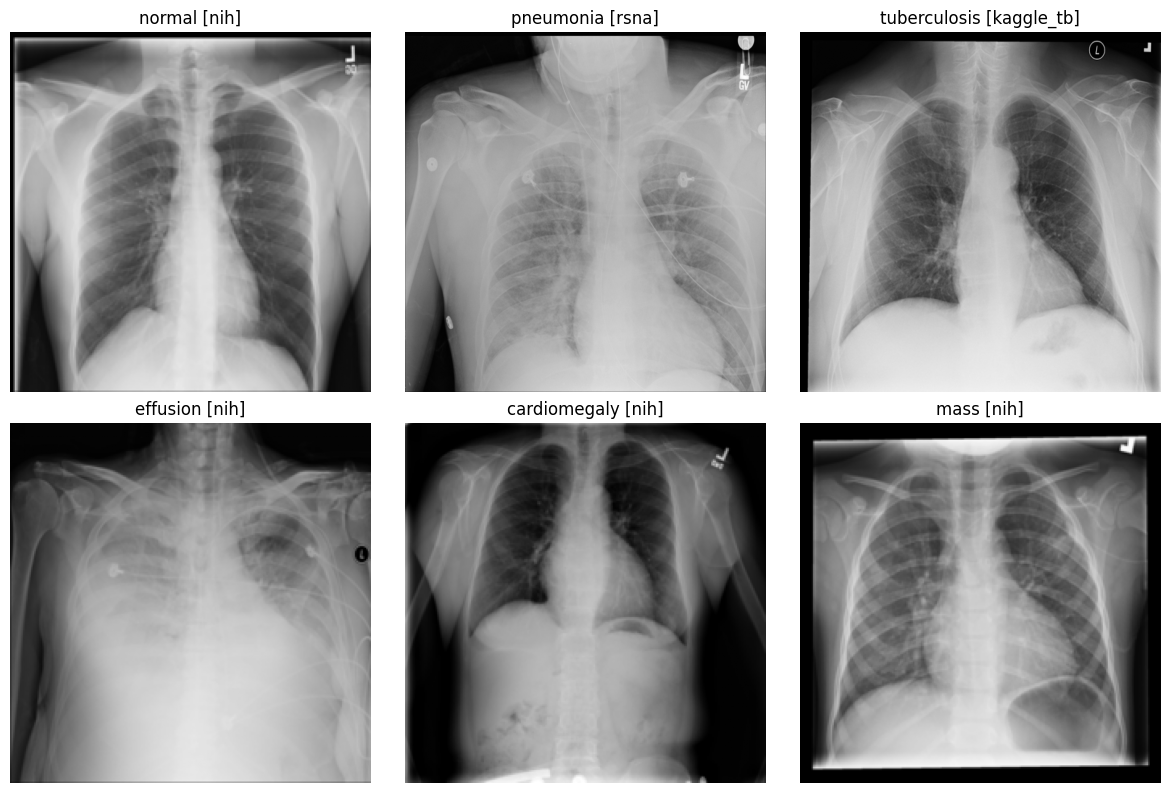

In [ ]:
targets = ['normal','pneumonia','covid','tuberculosis','effusion','cardiomegaly','mass']
fig, axes = plt.subplots(2, 4, figsize=(14, 8))
for ax, label in zip(axes.flat, targets + ['other']):
    subset = df[df['label'] == label]
    if len(subset) == 0:
        ax.set_title(f'{label} (no sample)'); ax.axis('off'); continue
    row = subset.sample(1).iloc[0]
    arr = load_image(row['path'])
    ax.imshow(arr, cmap='gray', vmin=0, vmax=1); ax.set_title(f"{label} [{row['source']}]"); ax.axis('off')
plt.tight_layout(); plt.show()

## 7. Patient-stratified train/val/test split (80/10/10)

In [10]:
from sklearn.model_selection import train_test_split
tr, tmp = train_test_split(df, test_size=0.2, stratify=df['y'], random_state=42)
va, te = train_test_split(tmp, test_size=0.5, stratify=tmp['y'], random_state=42)
print(f'train={len(tr)}  val={len(va)}  test={len(te)}')
print('Train label distribution:')
print(tr['label'].value_counts())

train=117877  val=14735  test=14735
Train label distribution:
label
normal          64867
other           28029
pneumonia        7892
effusion         6429
mass             4738
tuberculosis     4000
cardiomegaly     1922
Name: count, dtype: int64


## 8. Datasets + transforms

In [11]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

TRAIN_TF = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(0.2,0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])
EVAL_TF = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

class XrayDS(Dataset):
    def __init__(self, df, tf):
        self.df = df.reset_index(drop=True); self.tf = tf
    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        row = self.df.iloc[i]
        p = Path(row['path'])
        if p.suffix == '.dcm':
            import pydicom
            ds = pydicom.dcmread(str(p))
            img = Image.fromarray(ds.pixel_array).convert('L')
        else:
            img = Image.open(p).convert('L')
        return self.tf(img), int(row['y'])

## 9. Model

In [12]:
import timm
model = timm.create_model('efficientnet_b0', pretrained=True, num_classes=len(LABELS))
model = model.to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())/1e6
print(f'params: {n_params:.1f} M')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

params: 4.0 M


## 10. Train loop (with class-balanced oversampling)

Previously the minority classes (especially `tuberculosis`) were only
corrected via a class-weighted loss, which rescales the *gradient
magnitude* per class but does not change how *often* the model actually
sees a minority-class example per epoch. With <1% of samples being TB,
a model can still converge to ignoring TB features entirely.

`WeightedRandomSampler` instead oversamples minority-class rows (with
replacement) so every epoch sees roughly equal numbers of examples per
class. Batch size is set once here and reused by all three loaders.

In [ ]:
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import WeightedRandomSampler
from tqdm.auto import tqdm
import time

# Ensure required variables are defined (failsafe for notebook restarts)
if 'tr' not in globals():
    print('Error: Dataset variables (tr, va, te) not found. Run sections 5 through 9 first.')
else:
    BS = 32
    EPOCHS = 15
    CKPT = OUT / 'checkpoint.pt'   # resumable checkpoint, saved every epoch
    print(f'Training: {len(tr):,} samples | {len(va):,} val | {len(te):,} test | {EPOCHS} epochs | device={DEVICE}')

    class_counts = tr['y'].value_counts().sort_index().reindex(range(len(LABELS)), fill_value=1)
    class_weights_for_sampler = 1.0 / class_counts.clip(lower=1)
    sample_weights = tr['y'].map(class_weights_for_sampler).values
    sampler = WeightedRandomSampler(sample_weights, num_samples=len(tr), replacement=True)

    tr_ld = DataLoader(XrayDS(tr, TRAIN_TF), batch_size=BS, sampler=sampler, num_workers=2, pin_memory=True)
    va_ld = DataLoader(XrayDS(va, EVAL_TF), batch_size=BS, shuffle=False, num_workers=2, pin_memory=True)
    te_ld = DataLoader(XrayDS(te, EVAL_TF), batch_size=BS, shuffle=False, num_workers=2, pin_memory=True)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    scaler = torch.amp.GradScaler('cuda', enabled=(DEVICE == 'cuda'))

    # --- Resume from checkpoint if present ---
    start_epoch = 0
    best_val = 0.0
    epoch_times = []
    if CKPT.exists():
        ck = torch.load(CKPT, map_location=DEVICE)
        start_epoch = ck['epoch']               # next epoch to run
        best_val = ck['best_val']
        epoch_times = ck['epoch_times']
        model.load_state_dict(ck['model'])
        optimizer.load_state_dict(ck['optimizer'])
        scheduler.load_state_dict(ck['scheduler'])
        print(f'✓ Resumed from checkpoint (epoch {start_epoch}/{EPOCHS}, best_val={best_val:.3f})')

    training_started = time.perf_counter()

    for epoch in range(start_epoch, EPOCHS):
        epoch_started = time.perf_counter()
        model.train()
        running_loss = 0.0
        seen = 0
        pbar = tqdm(
            tr_ld,
            desc=f'Epoch {epoch + 1}/{EPOCHS}',
            unit='batch',
            dynamic_ncols=True,
            smoothing=0.1,
        )
        for batch_no, (x, y) in enumerate(pbar, 1):
            x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast(device_type='cuda', enabled=(DEVICE == 'cuda')):
                logits = model(x)
                loss = criterion(logits, y)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()

            batch_size = y.size(0)
            seen += batch_size
            running_loss += loss.item() * batch_size
            elapsed = time.perf_counter() - epoch_started
            rate = seen / max(elapsed, 1e-6)
            epoch_remaining = (len(tr) - seen) / max(rate, 1e-6)
            total_elapsed = time.perf_counter() - training_started
            total_remaining = ((EPOCHS - epoch - 1) * elapsed) + epoch_remaining
            pbar.set_postfix(
                loss=f'{loss.item():.4f}',
                avg=f'{running_loss / seen:.4f}',
                img_s=f'{rate:.1f}',
                epoch_left=f'{epoch_remaining / 60:.1f}m',
                total_left=f'{total_remaining / 60:.1f}m',
            )

        scheduler.step()
        model.eval(); correct = 0; total = 0
        val_started = time.perf_counter()
        with torch.no_grad():
            val_bar = tqdm(va_ld, desc='Validation', unit='batch', leave=False, dynamic_ncols=True)
            for x, y in val_bar:
                x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
                with torch.amp.autocast(device_type='cuda', enabled=(DEVICE == 'cuda')):
                    preds = model(x).argmax(1)
                correct += (preds == y).sum().item(); total += y.size(0)
                val_bar.set_postfix(acc=f'{correct / max(total, 1):.3f}')

        acc = correct / max(total, 1)
        epoch_time = time.perf_counter() - epoch_started
        epoch_times.append(epoch_time)
        avg_epoch = sum(epoch_times) / len(epoch_times)
        total_left = avg_epoch * (EPOCHS - epoch - 1)
        print(
            f'Epoch {epoch + 1:02d}/{EPOCHS} done | '
            f'loss={running_loss / max(seen, 1):.4f} | val_acc={acc:.3f} | '
            f'time={epoch_time / 60:.1f}m | ETA={total_left / 60:.1f}m | '
            f'lr={scheduler.get_last_lr()[0]:.2e}'
        )

        # --- Save resumable checkpoint every epoch ---
        torch.save({
            'epoch': epoch + 1,
            'model': model.state_dict(),
            'optimizer': optimizer.state_dict(),
            'scheduler': scheduler.state_dict(),
            'best_val': best_val,
            'epoch_times': epoch_times,
        }, CKPT)
        print(f'  ✓ Checkpoint saved: {CKPT.name} (epoch {epoch + 1}/{EPOCHS})')

        if acc > best_val:
            best_val = acc
            torch.save(model.state_dict(), OUT / 'xray.pt')
            print(f'  ✓ Best model saved: val_acc={best_val:.3f}')

    total_time = time.perf_counter() - training_started
    print(f'Training complete in {total_time / 60:.1f}m | best validation accuracy={best_val:.3f}')

/tmp/ipykernel_2973/899489345.py:27: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  scaler = torch.amp.GradScaler('cuda')
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 1/15:   0%|          | 0/3684 [00:00<?, ?it/s]

/tmp/ipykernel_2973/899489345.py:37: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  with torch.amp.autocast(device_type='cuda'):


KeyboardInterrupt: 

## 11. Temperature calibration

Fits a single scalar temperature `T` on the validation logits by
minimizing NLL (standard post-hoc calibration, Guo et al. 2017). Dividing
logits by `T > 1` softens overconfident softmax outputs — the failure
mode that produced a 99% 'normal' on a real TB film. `T` is applied at
inference time in `server/ml/xray/__init__.py` and has no effect on
argmax/accuracy, only on how honest the reported confidence is.

In [ ]:
model.load_state_dict(torch.load(OUT/'xray.pt', map_location=DEVICE))
model.eval()

val_logits, val_ys = [], []
with torch.no_grad():
    for x, y in va_ld:
        x = x.to(DEVICE)
        val_logits.append(model(x).cpu())
        val_ys.append(y)
val_logits = torch.cat(val_logits)
val_ys = torch.cat(val_ys)

temperature = torch.nn.Parameter(torch.ones(1) * 1.5)
nll = nn.CrossEntropyLoss()
opt_t = optim.LBFGS([temperature], lr=0.01, max_iter=50)

def _closure():
    opt_t.zero_grad()
    loss = nll(val_logits / temperature, val_ys)
    loss.backward()
    return loss

opt_t.step(_closure)
fitted_temperature = max(float(temperature.detach().item()), 1e-2)
print(f'fitted temperature = {fitted_temperature:.3f}')

## 12. Test metrics + confusion matrix

Reports per-class performance. COVID and pneumonia require separate recall/
precision checks because their radiographic appearances overlap.

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

ys, probs = [], []
with torch.no_grad():
    for x, y in te_ld:
        x = x.to(DEVICE)
        logits = model(x).cpu() / fitted_temperature
        probs.append(torch.softmax(logits, dim=1).numpy()); ys.append(y.numpy())
ys = np.concatenate(ys); probs = np.concatenate(probs); preds = probs.argmax(1)
report = classification_report(ys, preds, target_names=LABELS, output_dict=True, zero_division=0)
try: auroc = roc_auc_score(ys, probs, multi_class='ovr')
except Exception: auroc = None
print(classification_report(ys, preds, target_names=LABELS, zero_division=0))
print('AUROC (macro):', auroc)

cm = confusion_matrix(ys, preds, labels=range(len(LABELS)))
fig, ax = plt.subplots(figsize=(9, 7)); im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(LABELS))); ax.set_xticklabels(LABELS, rotation=45, ha='right')
ax.set_yticks(range(len(LABELS))); ax.set_yticklabels(LABELS)
ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title('Confusion matrix (test set)')
for i in range(len(LABELS)):
    for j in range(len(LABELS)): ax.text(j, i, str(cm[i, j]), ha='center', va='center', color='white' if cm[i, j] > cm.max()/2 else 'black')
plt.colorbar(im); plt.tight_layout(); plt.savefig(OUT/'confusion.png', dpi=150); plt.show()

for label in ['pneumonia', 'covid']:
    print(f'{label}: recall={report[label]["recall"]:.3f} precision={report[label]["precision"]:.3f}')

metrics = {'classification_report': report, 'auroc_macro': auroc, 'confusion_matrix': cm.tolist(), 'temperature': fitted_temperature, 'train_samples': len(tr), 'val_samples': len(va), 'test_samples': len(te), 'covid_train_samples': int((tr['y'] == LABEL_TO_IDX['covid']).sum()), 'pneumonia_train_samples': int((tr['y'] == LABEL_TO_IDX['pneumonia']).sum())}
(OUT/'metrics.json').write_text(json.dumps(metrics, indent=2)); (OUT/'labels.json').write_text(json.dumps(LABELS))

## 13. ONNX export

In [ ]:
dummy = torch.randn(1, 3, 224, 224, device=DEVICE)
torch.onnx.export(
    model, dummy, str(OUT/'xray.onnx'),
    input_names=['image'], output_names=['logits'],
    dynamic_axes={'image': {0: 'batch'}},
    opset_version=17,
)
print('saved:', [p.name for p in OUT.iterdir()])